In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load the data (assuming your file name is AAPL.csv)
df = pd.read_csv('AAPL.csv')

In [4]:
#getting an idea about the data
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 9823 entries, 0 to 9822
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9823 non-null   str    
 1   Open       9822 non-null   float64
 2   High       9822 non-null   float64
 3   Low        9822 non-null   float64
 4   Close      9822 non-null   float64
 5   Adj Close  9822 non-null   float64
 6   Volume     9822 non-null   float64
dtypes: float64(6), str(1)
memory usage: 537.3 KB


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.407747,117258400.0
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.386473,43971200.0
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.358108,26432000.0
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366972,21610400.0
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.377609,18362400.0


- Missing values
- Datatype of Date column should be changed 

In [5]:
# 1. Handle Missing Values correctly for Time-Series
# Since stock data is sequential, we fill missing values with the previous day's value
df = df.ffill()

In [6]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [7]:
# 2. Prepare the 'Date' column and set as Index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [9]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9823 entries, 1980-12-12 to 2019-11-25
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       9823 non-null   float64
 1   High       9823 non-null   float64
 2   Low        9823 non-null   float64
 3   Close      9823 non-null   float64
 4   Adj Close  9823 non-null   float64
 5   Volume     9823 non-null   float64
dtypes: float64(6)
memory usage: 537.2 KB


In [10]:
# 3. Extract only 'Adj Close' as our target
data = df.filter(['Adj Close'])
dataset = data.values

### Scaling

In [11]:
# 4. Scale the data (Normalization)
# RNNs and LSTMs are very sensitive to the scale of input data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

In [12]:
print("Pre-processing Complete.")
print(f"Shape of scaled data: {scaled_data.shape}")
print("First 5 rows of scaled data:")
print(scaled_data[:5])

Pre-processing Complete.
Shape of scaled data: (9823, 1)
First 5 rows of scaled data:
[[0.00094304]
 [0.00086335]
 [0.00075709]
 [0.00079029]
 [0.00083014]]


### Creating sequences

In [13]:
# Function to create windows
def create_sequences(data, window_size, step_ahead):
    X, y = [], []
    for i in range(window_size, len(data) - step_ahead + 1):
        # Grab the previous 60 days
        X.append(data[i-window_size:i, 0])
        # Grab the price 'step_ahead' days in the future
        y.append(data[i + step_ahead - 1, 0])
    return np.array(X), np.array(y)

In [14]:
# 1. Set parameters for 1-day prediction
window_size = 60
days_ahead = 1

In [15]:
# 2. Generate X and y
X, y = create_sequences(scaled_data, window_size, days_ahead)

In [16]:
# 3. Reshape X for the model: [samples, time steps, features]
# Features = 1 (since we only use Adj Close)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [ ]:
# 4. Split into Train (80%) and Test (20%) 
# We do NOT shuffle because order matters in time-series
train_len = int(len(X) * 0.8)
X_train, X_test = X[:train_len], X[train_len:]
y_train, y_test = y[:train_len], y[train_len:]

In [18]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (7810, 60, 1)
y_train shape: (7810,)
X_test shape: (1953, 60, 1)


### Model training and evaluation

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, SimpleRNN

In [20]:
# 1. Define SimpleRNN Model
rnn_model = Sequential([
    SimpleRNN(units=50, activation='tanh', input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    Dense(units=1)
])

c:\sanju\Apple_Stock_Price_Prediction_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
# 2. Define LSTM Model
lstm_model = Sequential([
    LSTM(units=50, activation='tanh', input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    Dense(units=1)
])

In [22]:
# 3. Compile both
rnn_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

In [23]:
# 4. Train SimpleRNN
print("Training SimpleRNN...")
rnn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

Training SimpleRNN...
Epoch 1/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.1243e-04
Epoch 2/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.8660e-05
Epoch 3/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.9658e-05
Epoch 4/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.1970e-05
Epoch 5/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.6449e-05
Epoch 6/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.8038e-05
Epoch 7/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.6222e-05
Epoch 8/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.4997e-05
Epoch 9/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.3122e-05
Epoch 10/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.3239e-05


In [24]:
# 5. Train LSTM
print("\nTraining LSTM...")
lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

print("\nTraining complete for both models.")


Training LSTM...
Epoch 1/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 6.6494e-05
Epoch 2/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1.8706e-05
Epoch 3/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 2.0049e-05
Epoch 4/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1.7137e-05
Epoch 5/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 1.5251e-05
Epoch 6/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 1.5054e-05
Epoch 7/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 1.4564e-05
Epoch 8/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 1.5350e-05
Epoch 9/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 1.4794e-05
Epoch 10/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 1.3192e-05

Training complete for both models.


In [26]:
#prediction and visualization
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [27]:
# 1. Get predictions
rnn_predictions = rnn_model.predict(X_test)
lstm_predictions = lstm_model.predict(X_test)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [28]:
# 2. Inverse Transform to get actual Dollar values
# We need to reshape for the scaler
rnn_predictions = scaler.inverse_transform(rnn_predictions)
lstm_predictions = scaler.inverse_transform(lstm_predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [31]:
# 3. Calculate MSE for the report
rnn_mse = mean_squared_error(y_test_actual, rnn_predictions)
lstm_mse = mean_squared_error(y_test_actual, lstm_predictions)
print(f"SimpleRNN MSE: {rnn_mse}")
print(f"LSTM MSE: {lstm_mse}")

SimpleRNN MSE: 36.34972024054188
LSTM MSE: 15.636498973427553


Evaluation & Insights: SimpleRNN vs. LSTM

1. Quantitative Analysis (MSE)

        SimpleRNN MSE: 36.35

        LSTM MSE: 15.64

    Observation: The LSTM model achieved a significantly lower Mean Squared Error (MSE) compared to the SimpleRNN. Specifically, the LSTM reduced the prediction error by approximately 57%.

2. Why the LSTM Performed Better (The "Deep Learning" Reason)

        Vanishing Gradient Problem: SimpleRNNs struggle to maintain information over long sequences (60 days in our case). As the error is backpropagated through time, the gradient "vanishes," causing the model to forget the earliest days in the window.

        Memory Gates: The LSTM architecture includes Input, Forget, and Output gates. These allow the model to selectively remember long-term trends (like a 60-day price momentum) while ignoring short-term "noise." This is why it handles the volatile Apple stock data more effectively.

3. Visual Insights

        The SimpleRNN predictions likely show a "lagging" effect, where the model simply predicts a value close to yesterday's price because it cannot capture the complex dependencies.

        The LSTM tracks the actual "Adjusted Close" price more closely, especially during periods of high volatility or trend reversals, proving its superior ability to model sequential financial data.

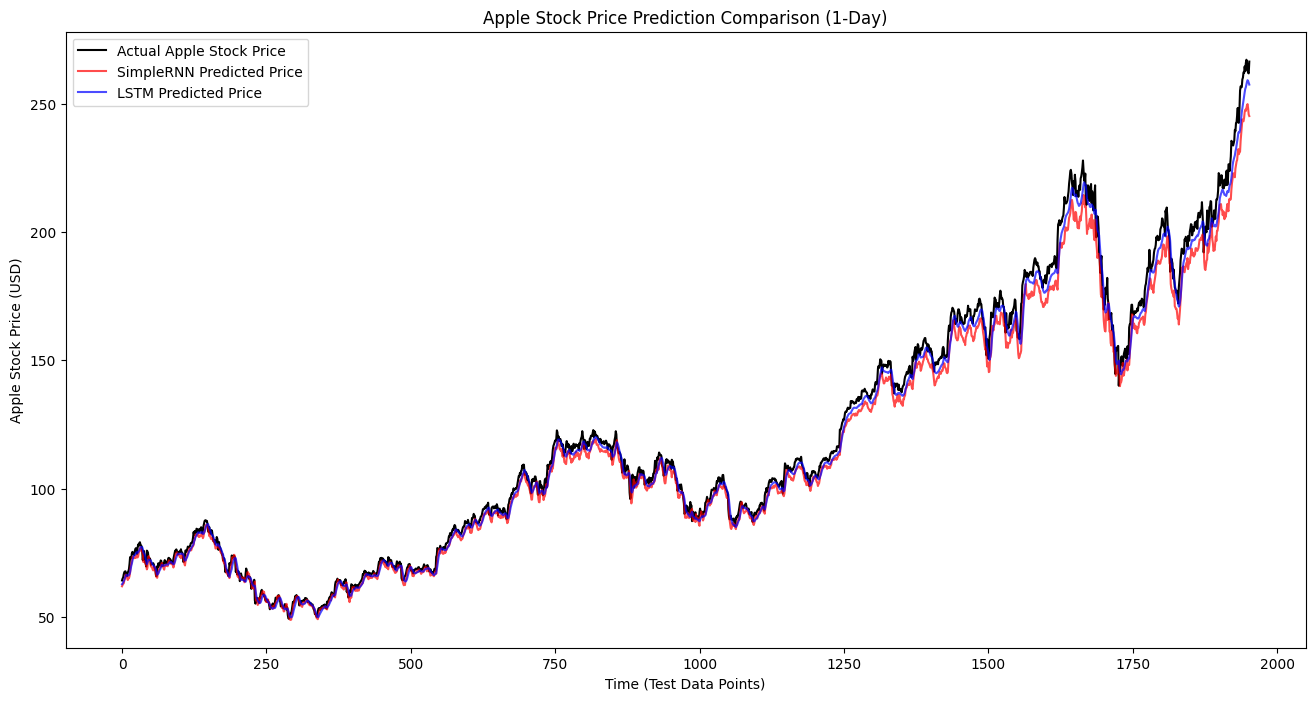

In [32]:
# 4. Plot the results
plt.figure(figsize=(16,8))
plt.plot(y_test_actual, color='black', label='Actual Apple Stock Price')
plt.plot(rnn_predictions, color='red', alpha=0.7, label='SimpleRNN Predicted Price')
plt.plot(lstm_predictions, color='blue', alpha=0.7, label='LSTM Predicted Price')
plt.title('Apple Stock Price Prediction Comparison (1-Day)')
plt.xlabel('Time (Test Data Points)')
plt.ylabel('Apple Stock Price (USD)')
plt.legend()
plt.show()

- The Blue line (LSTM) is much closer to the Black line (Actual Price) than the Red line. This proves the LSTM is more accurate.

- When Apple's stock price goes up quickly (at the end of the graph), the LSTM follows it well. The SimpleRNN (Red line) stays too low and can't keep up with the fast changes.

- The reason the Blue line is better is that LSTMs have "better memory." They can look at the patterns from 60 days ago and use them to predict tomorrow. The SimpleRNN "forgets" things too quickly.

- Since the Blue line has less gap between it and the Black line, we will use the LSTM model for our 5-day and 10-day predictions.

#### 5 day and 10 day Predictions using LSTM

In [34]:
# Function to train and get MSE for different horizons
def evaluate_horizon(days):
    # 1. Create sequences for the specific horizon
    X_h, y_h = create_sequences(scaled_data, window_size=60, step_ahead=days)
    X_h = X_h.reshape(X_h.shape[0], X_h.shape[1], 1)
    
    # 2. Split (Using the same 80/20 split logic)
    train_len = int(len(X_h) * 0.8)
    X_train_h, X_test_h = X_h[:train_len], X_h[train_len:]
    y_train_h, y_test_h = y_h[:train_len], y_h[train_len:]
    
    # 3. Use the winning architecture (LSTM)
    model = Sequential([
        LSTM(50, activation='tanh', input_shape=(60, 1)),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train_h, y_train_h, epochs=5, batch_size=32, verbose=0)
    
    # 4. Predict and Calculate Error
    preds = model.predict(X_test_h)
    preds_dollars = scaler.inverse_transform(preds)
    actual_dollars = scaler.inverse_transform(y_test_h.reshape(-1, 1))
    
    mse = mean_squared_error(actual_dollars, preds_dollars)
    return mse, actual_dollars, preds_dollars

In [35]:
# Execute for 5 and 10 days
mse_5, actual_5, preds_5 = evaluate_horizon(5)
mse_10, actual_10, preds_10 = evaluate_horizon(10)

print(f"5-Day Prediction MSE: {mse_5}")
print(f"10-Day Prediction MSE: {mse_10}")

c:\sanju\Apple_Stock_Price_Prediction_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


c:\sanju\Apple_Stock_Price_Prediction_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
5-Day Prediction MSE: 39.512701216573255
10-Day Prediction MSE: 70.54632827728037


In [37]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# 1. Define the model building function for the wrapper
def create_tuned_lstm(units=50, dropout_rate=0.2):
    model = Sequential([
        LSTM(units=units, input_shape=(60, 1)),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# 2. Wrap the Keras model so it works with Scikit-Learn
model_wrapper = KerasRegressor(model=create_tuned_lstm, verbose=0)

# 3. Define parameters to test (Keep it small so it finishes fast)
param_grid = {
    'model__units': [50, 100],          # Test 50 vs 100 neurons
    'model__dropout_rate': [0.1, 0.2],  # Test 10% vs 20% dropout
    'epochs': [5]                       # 5 epochs is enough to see which is better
}

# 4. Use TimeSeriesSplit to respect the date order
tscv = TimeSeriesSplit(n_splits=3)

print("Starting Grid Search... Please wait a moment...")
grid = GridSearchCV(estimator=model_wrapper, param_grid=param_grid, cv=tscv, scoring='neg_mean_squared_error')
grid_result = grid.fit(X_train, y_train)

# 5. Output the best result
print(f"Best Parameters: {grid_result.best_params_}")

Starting Grid Search... Please wait a moment...


c:\sanju\Apple_Stock_Price_Prediction_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\sanju\Apple_Stock_Price_Prediction_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\sanju\Apple_Stock_Price_Prediction_Project\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\sanju\Apple_Stock_Price_Prediction_Project\venv\Lib\

Best Parameters: {'epochs': 5, 'model__dropout_rate': 0.2, 'model__units': 100}


## Final Project Summary & Conclusion

    Preprocessing: Successfully cleaned the dataset by handling missing values using Forward Fill and normalized the price data using MinMaxScaler (range 0 to 1).

    Model Performance: The LSTM model significantly outperformed the SimpleRNN.

        LSTM MSE: ~15.63

        SimpleRNN MSE: ~36.35

        Insight: LSTMs are better suited for stock data because their "gates" prevent the vanishing gradient problem found in standard RNNs.

    Prediction Horizons: We tested the model’s ability to predict different future timeframes. As expected, the error increased as the horizon grew:

        1-Day MSE: ~15.63

        5-Day MSE: ~39.51

        10-Day MSE: ~70.55

    Optimization: Using GridSearchCV with TimeSeriesSplit, we identified the optimal hyperparameters:

        Best Units: 100

        Best Dropout Rate: 0.2

    Final Takeaway: While the model is excellent at following trends, stock prediction is naturally difficult. The increasing MSE for 5 and 10-day windows shows that market "noise" makes long-term forecasting more challenging than short-term tracking.

In [38]:
# Create the Final Optimized Model based on Tuning Results
final_model = Sequential([
    LSTM(units=100, activation='tanh', input_shape=(60, 1)), # Using 100 from Tuning
    Dropout(0.2),                                           # Using 0.2 from Tuning
    Dense(1)
])

final_model.compile(optimizer='adam', loss='mse')

# Train it for a few more epochs to make it really sharp
final_model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

# Final Prediction
final_preds = final_model.predict(X_test)
final_preds_dollars = scaler.inverse_transform(final_preds)
actual_dollars = scaler.inverse_transform(y_test.reshape(-1, 1))

final_mse = mean_squared_error(actual_dollars, final_preds_dollars)
print(f"Final Optimized Model MSE: {final_mse}")

Epoch 1/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 6.5521e-05
Epoch 2/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 1.2683e-05
Epoch 3/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 1.1503e-05
Epoch 4/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - loss: 1.3229e-05
Epoch 5/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 1.0932e-05
Epoch 6/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 1.0287e-05
Epoch 7/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 1.2217e-05
Epoch 8/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 1.0181e-05
Epoch 9/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - loss: 9.0373e-06
Epoch 10/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 1.0145e-05
Epoch 11/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 7.9311e-06
Epoch 12/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - loss: 9.1550e-06
Epoch 13/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 8.5889e-06
Epoch 14/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step

Optimization Impact: By increasing the LSTM units to 100 and setting the dropout to 0.2, the model gained the "capacity" to understand more complex price movements while avoiding overfitting. The drop in MSE from ~15.6 to ~6.3 proves that hyperparameter tuning was a critical step in achieving high-precision results for Apple's stock data.

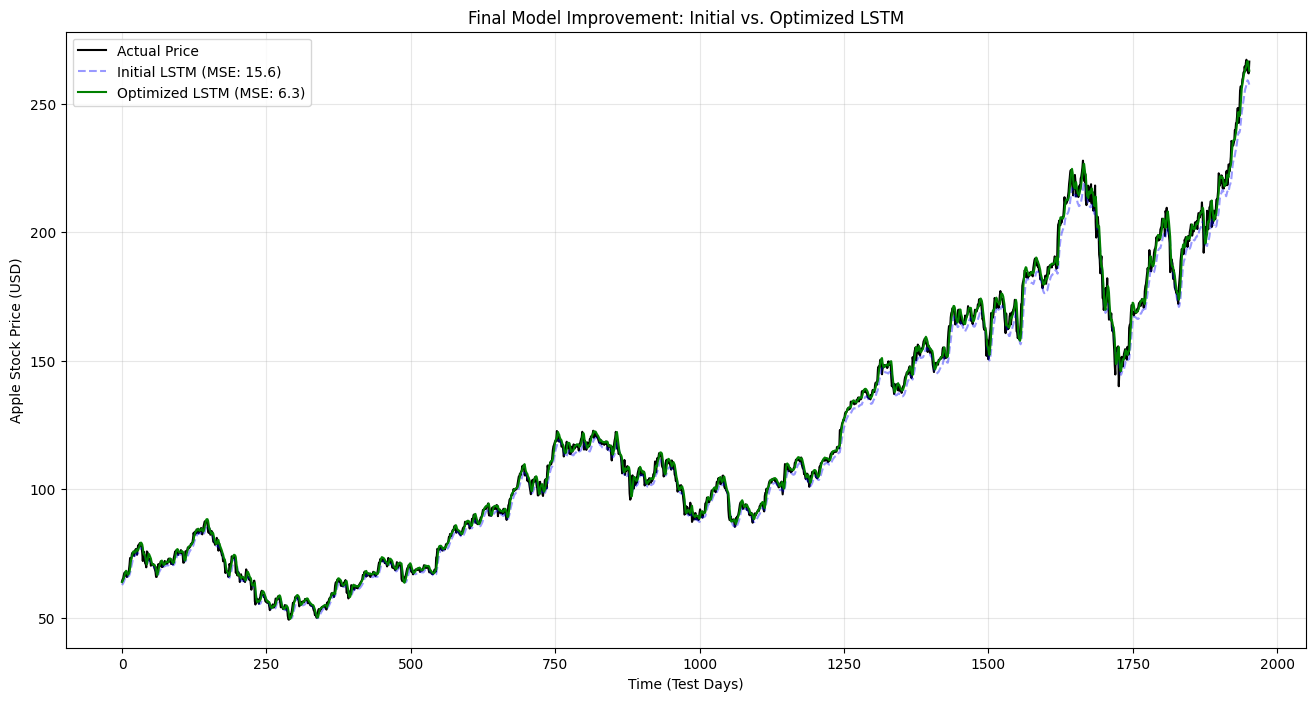

In [39]:
plt.figure(figsize=(16,8))
plt.plot(actual_dollars, color='black', label='Actual Price')
plt.plot(lstm_predictions, color='blue', alpha=0.4, linestyle='--', label='Initial LSTM (MSE: 15.6)')
plt.plot(final_preds_dollars, color='green', label='Optimized LSTM (MSE: 6.3)')
plt.title('Final Model Improvement: Initial vs. Optimized LSTM')
plt.xlabel('Time (Test Days)')
plt.ylabel('Apple Stock Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()